# Binary Decisions from Continuous Data

In {doc}`../07-bayesian-methods/optimal-decisions`, we considered optimal decision making in a discrete stochastic system (with discrete inputs and outputs) using a Bayesian framework. However, in many applications, the output of the system is continuous even if the input is discrete. For example, for a binary communication system, the input is bits, but the received noisy waveform is converted inside the receiver into a continuous random variable. Similarly, many medical tests for disease are based on chemical tests whose outputs are  continuous random variables. 

In this section, we consider scenarios in which the system input or hidden state is binary and the output is a continuous random variable. More specifically, we assume the data comes from one of two continuous densities, $f_0(x|H_0)$ or $f_1(x|H_1)$, and we wish to make a decision between $H_0$ and $H_1$ based on an observed value $x$. **Any** decision rule can then be written as follows. Let $\{R_0, R_1 \}$ be a partition of the real line. Then the decision rule is:
* If $x \in R_0$, decide $H_0$.
* If $x \in R_1$, decide $H_1$.

The regions $R_0$ and $R_1$ can be chosen to optimize some criteria that measures costs or rewards for making correct or erroneous decisions. Although $R_0$ and $R_1$ can generally be any Borel set, in practice they are often intervals that are determined by 
single threshold $\gamma$, like $R_0 = \{x|x < \gamma\}$ and $R_1 = \{x|x > \gamma\}$.



Consider a scenario where the *a priori* probabilities $P(H_0)$ and $P(H_1)$ are not known, and thus we cannot apply a Bayesian test. Then we might instead focus on determining $R_0$ and $R_1$ based on performance criteria that do not depend on these *a prioris*. In particular, we will use:
* the probability of false alarm, which we denote by $\alpha$, and
* the probability of miss, which we denote by $\beta$.

Let's introduce a concrete example to start to motivate our work:

**Example**

The PSA (Prostate-Specific Antigen) values for men in their 60s without cancer are approximately Gaussian(2,$\sigma=1$). The PSA values for men in their 60s with cancer are approximately Gaussian(4,$\sigma=1.5$).

Let $X$ denote the PSA value. Then the conditional densities for $X$ given $H_0$ and given $H_1$ are shown below:

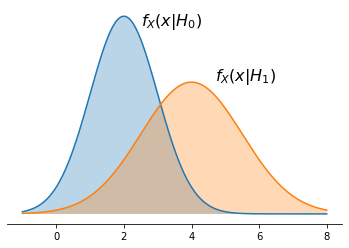

In [14]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt


G0 = stats.norm(loc = 2, scale = 1)
G1 = stats.norm(loc = 4, scale = 1.5)
x=np.linspace(-1,8,1001)


plt.plot(x,G0.pdf(x))
plt.plot(x,G1.pdf(x))

# Fill under the regions found above
plt.fill_between(x,G0.pdf(x),alpha=0.3)
plt.fill_between(x,G1.pdf(x),alpha=0.3)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

plt.annotate('$f_X(x|H_0)$', (2.5,0.38), fontsize=16)
plt.annotate('$f_X(x|H_1)$', (4.7,0.27), fontsize=16);

## Maximum Likelihood Decision Rule

Let's start by considering the maximum likelihood (ML) rule: 
* If $f_X(x|H_0) > f_X(x|H_1)$, decide $H_0$.
* If $f_X(x|H_0) \le f_X(x|H_1)$, decide $H_1$.

We can determine the ML decision region corresponding to $H_0$ by finding the values of $x$ where  $f_X(x|H_0) > f_X(x|H_1)$:

In [21]:
x=np.linspace(-10,10, 1001)
x[np.where(G0.pdf(x) > G1.pdf(x))]

array([-2.28, -2.26, -2.24, -2.22, -2.2 , -2.18, -2.16, -2.14, -2.12,
       -2.1 , -2.08, -2.06, -2.04, -2.02, -2.  , -1.98, -1.96, -1.94,
       -1.92, -1.9 , -1.88, -1.86, -1.84, -1.82, -1.8 , -1.78, -1.76,
       -1.74, -1.72, -1.7 , -1.68, -1.66, -1.64, -1.62, -1.6 , -1.58,
       -1.56, -1.54, -1.52, -1.5 , -1.48, -1.46, -1.44, -1.42, -1.4 ,
       -1.38, -1.36, -1.34, -1.32, -1.3 , -1.28, -1.26, -1.24, -1.22,
       -1.2 , -1.18, -1.16, -1.14, -1.12, -1.1 , -1.08, -1.06, -1.04,
       -1.02, -1.  , -0.98, -0.96, -0.94, -0.92, -0.9 , -0.88, -0.86,
       -0.84, -0.82, -0.8 , -0.78, -0.76, -0.74, -0.72, -0.7 , -0.68,
       -0.66, -0.64, -0.62, -0.6 , -0.58, -0.56, -0.54, -0.52, -0.5 ,
       -0.48, -0.46, -0.44, -0.42, -0.4 , -0.38, -0.36, -0.34, -0.32,
       -0.3 , -0.28, -0.26, -0.24, -0.22, -0.2 , -0.18, -0.16, -0.14,
       -0.12, -0.1 , -0.08, -0.06, -0.04, -0.02,  0.  ,  0.02,  0.04,
        0.06,  0.08,  0.1 ,  0.12,  0.14,  0.16,  0.18,  0.2 ,  0.22,
        0.24,  0.26,

So we will decide $H_0$ if $-2.28 \le X \le 3.08$ and decide $H_1$ otherwise. Note, however, that $P(X<-2.28|H_i)$ is **very small** for both $H_0$ and $H_1$:

In [22]:
G0.pdf(-2.28), G1.pdf(-2.28)

(4.198750293161747e-05, 4.1555007345160996e-05)

Thus, a simpler decision region with similar performance is:
* Decide $H_0$ if $X \le 3.08$.
* Decide $H_1$ if $X > 3.08$.

Recall that a false alarm is when $H_0$ is true but the decision is $H_1$. Since $H_0$ is true, the probability a false alarm corresponds to some region under the curve $f_X(x|H_0)$. For the ML detection rule, that region is $\{x|x > 3.08\}$, and the false alarm probability is shown below:

Text(2.5, 0.38, '$f_X(x|H_0)$')

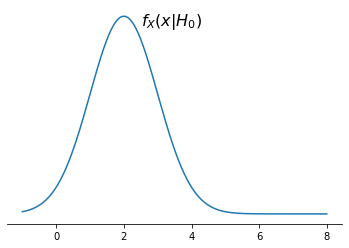

In [24]:
G0 = stats.norm(loc = 2, scale = 1)
x=np.linspace(-1,8,1001)


plt.plot(x,G0.pdf(x))

# Fill under the regions found above
#plt.fill_between(x,G0.pdf(x),alpha=0.3)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

plt.annotate('$f_X(x|H_0)$', (2.5,0.38), fontsize=16)


Similarly, a miss is when $H_1$ is true, but the decision is $H_0$. 

* The probability of false alarm and probability of miss then depend on the decision regions $R_0$ and $R_1$

## Example
 For $P_{fa} = 10$%, find $P_m$
    
\begin{align}
P_{fa} &= 0.1 \\
Q\left(\frac{\gamma-2}{\sqrt{\sigma^2}}\right) &= 0.1 \\
Q\left(\frac{\gamma-2}{\sqrt{1}}\right) &= 0.1 \\
\gamma - 2 &= Q^{-1}(0.1) \\
\gamma - 2 &= 1.28 \\
\gamma &\approx 3.28
\end{align}

\begin{align}
P_m = Q\left(\frac{4 - 3.28}{\sqrt{2}}\right) \approx 0.305
\end{align}

2. For $P_m = 10$%, find $P_{fa}$

\begin{align}
P_m &= 0.1 \\
Q\left(\frac{4 - \gamma}{\sqrt{2}}\right) &= 0.1 \\
\frac{4-\gamma}{\sqrt{2}} &\approx 1.28\\
\gamma &\approx 2.19
\end{align}

\begin{align}
P_{fa} = Q\left(\frac{2 - 2.19}{1}\right) \approx 0.425
\end{align}

# Visualizing Tradeoffs in Hypothesis Testing: ROC Curves

* We can visualize the relation between these types of errors using a ROC curve
    * ROC stands for *receiver operating characteristic*
    * ROC curves were developed for RADAR systems but are widely used in fields of statistical tests, such as biomedicine

* In ROC curves, we do not plot $P_{fa}$ vs $P_m$

* Instead:
    * the x-axis is **FPR (false positive rate)**
    $$\text{FPR}=P_{fa}$$
    * the y-axis is **TPR (true positive rate)**
    $$\text{TPR}=1-P_m$$

In [2]:
def Q(x):
    return stats.norm.sf(x)

In [3]:
fpr=[]
tpr=[]
for gamma in np.linspace(0,6,100):
    fpr+=[Q((gamma-2)/np.sqrt(1))]
    tpr+=[1-Q((4-gamma)/np.sqrt(2))]

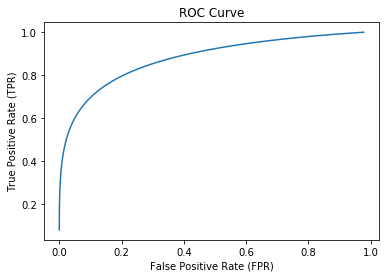

In [4]:
plt.plot(fpr,tpr);
plt.xlabel('False Positive Rate (FPR)'); 
plt.ylabel('True Positive Rate (TPR)');
plt.title('ROC Curve');

In [5]:
ref=np.linspace(0,1,50)

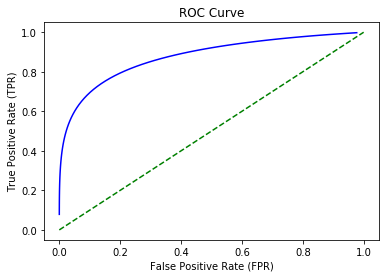

In [6]:
plt.plot(fpr,tpr,'b',ref,ref,'g--');
plt.xlabel('False Positive Rate (FPR)'); 
plt.ylabel('True Positive Rate (TPR)');
plt.title('ROC Curve');

## Area Under the Curve (AUC)

*Area Under Curve (AUC)* is a common measure of how good a test is. It is simply the area under the ROC curve. Random guessing can achieve the diagonal line, so the minimum AUC is 1/2. The maximum AUC is 1, which is achieved by a test that is always right; the ROC curve is along the left and top axes.

In [7]:
np.trapz(np.flip(tpr),x=np.flip(fpr))

0.853121150297299

## Exercise

Plot the performance if the variance of each PSA test is reduced by a factor of 4. What is the AUC?

In [10]:
ref=np.linspace(0,1,50)
fpr=[]
tpr=[]
for gamma in np.linspace(0,6,50):
    fpr+=[Q((gamma-2)/np.sqrt(1/4))]
    tpr+=[1-Q((4-gamma)/np.sqrt(2/4))]

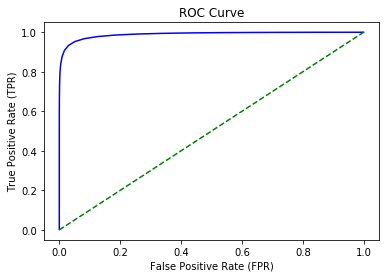

In [11]:
plt.plot(fpr,tpr,'b',ref,ref,'g--');
plt.xlabel('False Positive Rate (FPR)'); 
plt.ylabel('True Positive Rate (TPR)');
plt.title('ROC Curve');

In [12]:
np.trapz(np.flip(tpr),x=np.flip(fpr))

0.9892938656914673

# In-Class Assignment

Use the Student's $T$ random variable to determine a 95% confidence interval for the mean difference under the null hypothesis. Is the resulting confidence interval compatible with the observed difference of means?

*Hint:* The inverse CDF function in ```scipy.stats``` is called the Percent point function (PPF) and is given by the ```ppf``` method of random variable objects.